In [1]:
from tqdm import tqdm
import firebase_admin
from firebase_admin import credentials, firestore, auth
import matplotlib.pyplot as plt
import pandas as pd
from pandas import IndexSlice as ix
import numpy as np
from yaml import safe_load
import datetime
import pyxirr as xirr
import yfinance as yf

import plotly.io as pio
import plotly.express as px

In [2]:
def load_transactions():
    with open("portfolio.yaml", "rb") as f:
        portfolio = safe_load(f)
    return portfolio

# Transform dictionary into a dataframe of transaction records
def format_transactions(portfolio):
    records = []
    for ticker, transactions in portfolio.items():
        for date, details in transactions.items():
            qte = next((item['QTE'] for item in details if 'QTE' in item), None)
            price = next((pd.to_numeric(item['PRICE'], errors="coerce") for item in details if 'PRICE' in item), None)
            buy_price_yahoo = yf.download(
                ticker, start=date, end=date + datetime.timedelta(1), group_by="ticker", auto_adjust=True
            )[ticker]["Close"]

            if not buy_price_yahoo.empty:
                records.append({
                    'date': date, 'ticker': ticker, 'quantity_flow': qte, 'price': price, 'buy_price_yahoo': buy_price_yahoo.values[0],
                })
            else:
                records.append({
                    'date': date, 'ticker': ticker, 'quantity_flow': qte, 'price': price, 'buy_price_yahoo': np.nan,
                })

    # Convert to DataFrame
    df = pd.DataFrame(records)
    print(df.head())
    # Sort by Date
    df.sort_values(by=["ticker", "date"], inplace=True)

    # Reset index
    df.reset_index(drop=True, inplace=True)
    df.loc[df.price.isna(), "price"] = df.loc[df.price.isna(), "buy_price_yahoo"]

    df["spending_flow"] = df["quantity_flow"] * df["price"]
    df["spending_stock"] = df.groupby("ticker").spending_flow.cumsum()
    # df["invested_cash_flow"] = df["quantity_flow"].where(df["quantity_flow"] > 0) * df["price"]
    # df["PRU"] = df.groupby("ticker").invested_cash_flow.cumsum() / df.where(df["quantity_flow"] > 0).groupby("ticker").quantity_flow.cumsum()
    # df["invested_cash_flow"] = df["quantity_flow"] * df["price"]
    # df["invested_cash_stock"] = df.groupby("ticker").invested_cash_flow.cumsum()
    df["quantity_stock"] = df.groupby("ticker").quantity_flow.cumsum()


    df.drop(columns=["buy_price_yahoo"], inplace=True)

    return df


def fetch_hist_data(df, portfolio):
    # Downloading historical stock prices and merging with transaction records
    start_date = "2021-01-20"
    hist_data = yf.download(
        list(portfolio.keys()), start=start_date, 
        group_by="ticker", auto_adjust=True
    )
    hist_data = hist_data.stack(level=0, future_stack=True)
    hist_data.columns = hist_data.columns.values
    hist_data = hist_data.reset_index()
    hist_data = hist_data[["Date", "Ticker", "Close"]]
    hist_data.columns = [col.lower() for col in hist_data.columns]


    # Set start and end date
    start_date = pd.Timestamp("2021-01-20")
    end_date = datetime.datetime.today()

    # Create a complete date range
    all_dates = pd.date_range(start=start_date, end=end_date, freq="D")

    # Create a MultiIndex with all tickers and all dates
    multi_index = pd.MultiIndex.from_product([df["ticker"].unique(), all_dates], names=["ticker", "date"])

    # Reindex the DataFrame to expand the dates for all tickers
    full_df = df[["ticker", "date", "quantity_stock", "spending_stock"]]\
        .set_index(["ticker", "date"]).reindex(multi_index)

    # Forward-fill the quantity_stock column
    full_df["quantity_stock"] = full_df.groupby("ticker")["quantity_stock"].ffill()
    full_df["quantity_stock"] = full_df["quantity_stock"].fillna(0)

    # Forward-fill the spending_stock and invested_cash_stock columns
    full_df["spending_stock"] = full_df.groupby("ticker")["spending_stock"].ffill()
    # full_df["invested_cash_stock"] = full_df.groupby("ticker")["invested_cash_stock"].ffill()

    # full_df["PRU"] = full_df["PRU"].ffill()
    # Merge with transaction records
    hist_data = hist_data.merge(
        full_df, how='left',
        on=["ticker", "date"]
    )
    hist_data = hist_data.set_index(["ticker", "date",])
    # Réparation à la main du fait qu'il n'y a pas de données avant pour EWLD PA
    hist_data.loc[pd.IndexSlice["EWLD.PA", "2021-01-20"], "close"] = 20.59
    hist_data.loc[pd.IndexSlice["EWLD.PA", "2021-01-25"], "close"] = 20.59
    hist_data.loc[pd.IndexSlice["EWLD.PA", :], "close"] = hist_data.loc[pd.IndexSlice["EWLD.PA", :], "close"].interpolate()
    # Compute daily values of each stock
    hist_data["valuation"] = hist_data["quantity_stock"] * hist_data["close"]
    # hist_data["PRU"] = hist_data["invested_cash_stock"] / hist_data["quantity_stock"] 
    # hist_data["prix_achat"] = hist_data["PRU"] * hist_data["quantity_stock"] 

    # Compute the balance (profit or loss) of each stock
    # hist_data["balance"] = hist_data["valuation"] - hist_data["spending_stock"]
    hist_data["balance"] = (
        hist_data.valuation
        - hist_data.loc[
            hist_data.quantity_stock > 0
        ].spending_stock
    ).fillna(0)
    # Compute profit rate of each stock with respect to investments made
    hist_data["profit_rate"] = hist_data["balance"] / hist_data["spending_stock"]

    # Set to NaN spending_stock and invested_cash_stock whenever the daily prices were not retrieved
    # e.g when a stock has been delisted or integrated into another ticker
    # Otherwise, the cash spent on such stocks will be taken into account in the computation of profit
    # while the daily values are NaN, thus artificially deflating profits
    hist_data["spending_stock"] = hist_data["spending_stock"].where(~hist_data["close"].isna(), np.nan)
    # hist_data["invested_cash_stock"] = hist_data["invested_cash_stock"].where(~hist_data["close"].isna(), np.nan)
    return hist_data


In [3]:


# # Initialize Firebase
# if not firebase_admin._apps:
#     cred = credentials.Certificate(".streamlit/firebase-credentials.json")
#     firebase_admin.initialize_app(cred)

# db = firestore.client()

# Load 10,000 rows of data into the dataframe.
portfolio = load_transactions()

# Load 10,000 rows of data into the dataframe.
df = format_transactions(portfolio)

# Load 10,000 rows of data into the dataframe.
hist_data = fetch_hist_data(df, portfolio)

text_to_var_name = {
    "Profit rate": "profit_rate",
    "Portfolio value": "valuation",
}

# year_range = st.slider('year', 2020, datetime.datetime.today().year, 2020)
# fig = px.line(
#     hist_data.loc[hist_data.index.get_level_values("date").year >= year_range].reset_index(), 
#     x="date", 
#     y=text_to_var_name[variable], 
#     color="ticker", 
#     title=f"{variable} over Time",
#     labels={text_to_var_name[variable]: variable, "date": "Date"},
# )


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['EWLD.PA']: YFPricesMissingError('possibly delisted; no price data found  (1d 2021-01-25 -> 2021-01-26) (Yahoo error = "Data doesn\'t exist for startDate = 1611529200, endDate = 1611615600")')
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%*

         date   ticker  quantity_flow   price  buy_price_yahoo
0  2025-12-12  DCAM.PA              2   5.420            5.358
1  2025-12-11  DCAM.PA              3   5.388            5.391
2  2025-12-08  DCAM.PA              1   5.429            5.417
3  2025-12-09  DCAM.PA             88   5.427            5.422
4  2021-01-25  EWLD.PA              4  20.590              NaN


[*********************100%***********************]  10 of 10 completed


In [4]:
def rolling_irr(df, days=6, end_date=None,
                date_col="date", contrib_col="spending_stock", balance_col="valuation"):

    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col)

    # --- determine end date ---
    if end_date is None:
        end_date = df[date_col].iloc[-1]
    else:
        end_date = pd.to_datetime(end_date)

    # Ensure end_date exists in or after the dataframe range
    if end_date < df[date_col].min():
        raise ValueError("end_date is earlier than the first date in the dataframe.")
    if end_date > df[date_col].max():
        raise ValueError("end_date is later than the last date in the dataframe.")

    # --- determine rolling window start ---
    start_date = end_date - pd.DateOffset(days=days)

    # Subset to rolling window
    sub = df[df[date_col] >= start_date].copy()

    # Starting balance = last balance before the window starts
    prev_balances = df[df[date_col] < start_date][balance_col]
    if prev_balances.empty:
        raise ValueError("Not enough history before start_date to compute starting balance.")
    start_balance = prev_balances.iloc[-1]

    # Ending balance = balance at the chosen end_date
    # If the end_date is not exactly present, we take the nearest earlier date
    end_balance = df.loc[df[date_col] <= end_date, balance_col].iloc[-1]

    # Build cashflow dates
    dates = pd.Series([start_date - pd.DateOffset(days=1)] +
                      sub.loc[sub[date_col] <= end_date, date_col].tolist())

    # Build cashflows
    cashflows = [-start_balance]  # starting inflow
    contribs = (-sub.loc[sub[date_col] <= end_date, contrib_col]).tolist()
    cashflows += contribs

    # Add ending balance to last cashflow
    cashflows[-1] += end_balance

    irr = xirr.xirr(pd.Series(dates), cashflows)
    return irr

TWR

In [5]:
def rolling_twr_from_pivot(shares_df, price_df, days=365, last_date=None):
    if last_date is None:
        last_date = shares_df.index.max()
    else:
        last_date = pd.to_datetime(last_date)
    start_date = last_date - pd.Timedelta(days=days)

    sub_shares = shares_df.loc[start_date:last_date]
    sub_price  = price_df.loc[start_date:last_date]

    portfolio_value = (sub_shares * sub_price).sum(axis=1)
    shares_diff = sub_shares.diff().fillna(0)
    cash_flow = (shares_diff * sub_price).sum(axis=1)

    prev_value = portfolio_value.shift(1)
    daily_return = (portfolio_value - cash_flow) / prev_value - 1
    daily_return.iloc[0] = 0

    return (1 + daily_return).prod()**(365/days) - 1


In [6]:
df = pd.concat(
    (
        hist_data.groupby("date")["spending_stock"].sum().diff(),
        hist_data.groupby("date")["valuation"].sum(),
    ), axis=1
).dropna().reset_index()

irr = pd.DataFrame(index=df.date)
days = 365*1
for date in tqdm(irr.index, total=len(irr)):
    try:
        irr.loc[date, "irr"] = rolling_irr(
            df, days=days, end_date=date,date_col="date", contrib_col="spending_stock", balance_col="valuation"
        )
    except ValueError:
        continue

100%|██████████| 1260/1260 [00:07<00:00, 168.84it/s]


100%|██████████| 1261/1261 [00:04<00:00, 272.13it/s]


<Axes: xlabel='date'>

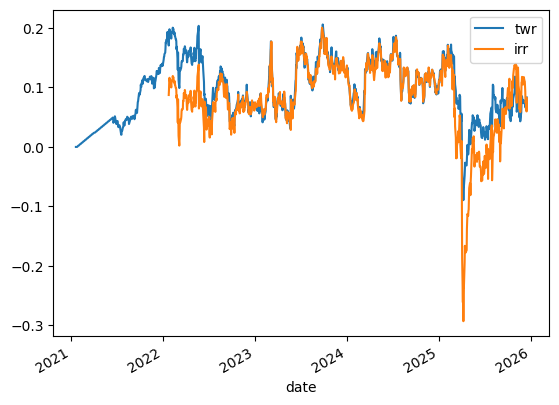

In [7]:
df = hist_data.copy()

df = df.reset_index()[["date", "ticker", "close", "quantity_stock"]].rename(
    columns={
        "quantity_stock": "shares",
        "close": "price",
        "ticker": "asset"
    }
)
shares_df = df.pivot(index="date", columns="asset", values="shares").fillna(0)
price_df  = df.pivot(index="date", columns="asset", values="price").fillna(0)
days = 365*1
twr = pd.DataFrame(index=df.date.unique())

for date in tqdm(twr.index, total = len(twr)):
    twr.loc[date, "twr"] = rolling_twr_from_pivot(
        shares_df, price_df, days=days, last_date=date,
    )
fig, ax = plt.subplots()
twr.dropna().plot(ax=ax)
irr.dropna().plot(ax=ax)